# Interpretação dos Modelos — Previsão de Cancelamentos e Atrasos em Voos

Este notebook aprofunda a interpretação dos dois modelos otimizados desenvolvidos na fase de modelação, utilizando técnicas visuais para extrair insights sobre o comportamento dos modelos, os grupos de maior risco e o impacto operacional das decisões.

| Target | Modelo | F1 | Average Precision | Threshold |
|--------|--------|----|-------------------|-----------|
| `cancelled` | HistGradientBoosting | 0.166 | 0.100 | 0.806 |
| `is_delayed` | HistGradientBoosting | 0.291 | 0.226 | 0.606 |

**Estrutura:**
1. Importância de features com intervalos de incerteza e análise de estabilidade
2. Análise de grupos de risco — dia da semana, mês e aeroporto
3. Curvas de desempenho — Precision-Recall, ROC, calibração e lift
4. Análise de erros — perfil dos falsos negativos
5. Análise de threshold — impacto operacional


## 0. Configuração

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from IPython.display import display
from pathlib import Path
import joblib
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    f1_score, recall_score, precision_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, confusion_matrix
)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
PALETTE  = sns.color_palette('muted')
COR_CANC = PALETTE[0]
COR_DEL  = PALETTE[1]

DIAS  = {1:'Seg', 2:'Ter', 3:'Qua', 4:'Qui', 5:'Sex', 6:'Sab', 7:'Dom'}
MESES = {1:'Janeiro', 2:'Fevereiro'}

print('Setup concluido.')


Setup concluido.


In [2]:
df = pd.read_csv('/kaggle/input/datasets/rodrigoramooos/flight-data-processed-updated/flight_data_processed_novo.csv')
feature_cols = [c for c in df.columns if c not in ('cancelled', 'is_delayed')]
origin_cols  = [c for c in feature_cols if c.startswith('origin_')]

THRESH_C, THRESH_D = 0.806, 0.606

X_c = df[feature_cols].astype('float32')
y_c = df['cancelled']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42, stratify=y_c)

df_del = df[df['cancelled'] == 0].copy()
X_d    = df_del[feature_cols].astype('float32')
y_d    = df_del['is_delayed']
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_d, y_d, test_size=0.2, random_state=42, stratify=y_d)

if Path('modelo_c.joblib').exists() and Path('modelo_d.joblib').exists():
    modelo_c = joblib.load('modelo_c.joblib')
    modelo_d = joblib.load('modelo_d.joblib')
    print('Modelos carregados de disco.')
else:
    modelo_c = HistGradientBoostingClassifier(
        learning_rate=0.1, max_depth=10, max_iter=200,
        min_samples_leaf=30, class_weight='balanced', random_state=42)
    modelo_c.fit(X_train_c, y_train_c)
    modelo_d = HistGradientBoostingClassifier(
        learning_rate=0.1, max_depth=10, max_iter=200,
        min_samples_leaf=30, class_weight='balanced', random_state=42)
    modelo_d.fit(X_train_d, y_train_d)
    joblib.dump(modelo_c, 'modelo_c.joblib')
    joblib.dump(modelo_d, 'modelo_d.joblib')
    print('Modelos treinados e guardados em disco.')

proba_c = modelo_c.predict_proba(X_test_c)[:, 1]
pred_c  = (proba_c >= THRESH_C).astype(int)
proba_d = modelo_d.predict_proba(X_test_d)[:, 1]
pred_d  = (proba_d >= THRESH_D).astype(int)

# ── Metadados ─────────────────────────────────────────────────────────────
def build_meta(df_src, idx, y_true, y_pred, proba, X_test):
    meta = df_src.loc[idx, ['day_of_week', 'month']].copy()
    meta['y_true'] = y_true.values
    meta['y_pred'] = y_pred
    meta['proba']  = proba
    meta['origin'] = (
        X_test[origin_cols].idxmax(axis=1)
        .str.replace('origin_', '', regex=False).values
    )
    return meta

df_meta_c = build_meta(df,     X_test_c.index, y_test_c, pred_c, proba_c, X_test_c)
df_meta_d = build_meta(df_del, X_test_d.index, y_test_d, pred_d, proba_d, X_test_d)

# ── Tabela de verificacao ─────────────────────────────────────────────────
verif = pd.DataFrame({
    'Target':    ['cancelled', 'is_delayed'],
    'F1':        [round(f1_score(y_test_c, pred_c, zero_division=0), 3),
                  round(f1_score(y_test_d, pred_d, zero_division=0), 3)],
    'Recall':    [round(recall_score(y_test_c, pred_c, zero_division=0), 3),
                  round(recall_score(y_test_d, pred_d, zero_division=0), 3)],
    'Precision': [round(precision_score(y_test_c, pred_c, zero_division=0), 3),
                  round(precision_score(y_test_d, pred_d, zero_division=0), 3)],
    'ROC-AUC':   [round(roc_auc_score(y_test_c, proba_c), 3),
                  round(roc_auc_score(y_test_d, proba_d), 3)],
    'Avg Precision': [round(average_precision_score(y_test_c, proba_c), 3),
                      round(average_precision_score(y_test_d, proba_d), 3)],
})
display(verif.set_index('Target'))


Modelos treinados e guardados em disco.


,F1,Recall,Precision,ROC-AUC,Avg Precision
Target,,,,,
cancelled,0.166,0.327,0.111,0.871,0.100
is_delayed,0.291,0.416,0.224,0.723,0.226


---

## 1. Importância de Features


### 1.1 cancelled

A calcular permutation importance para cancelled


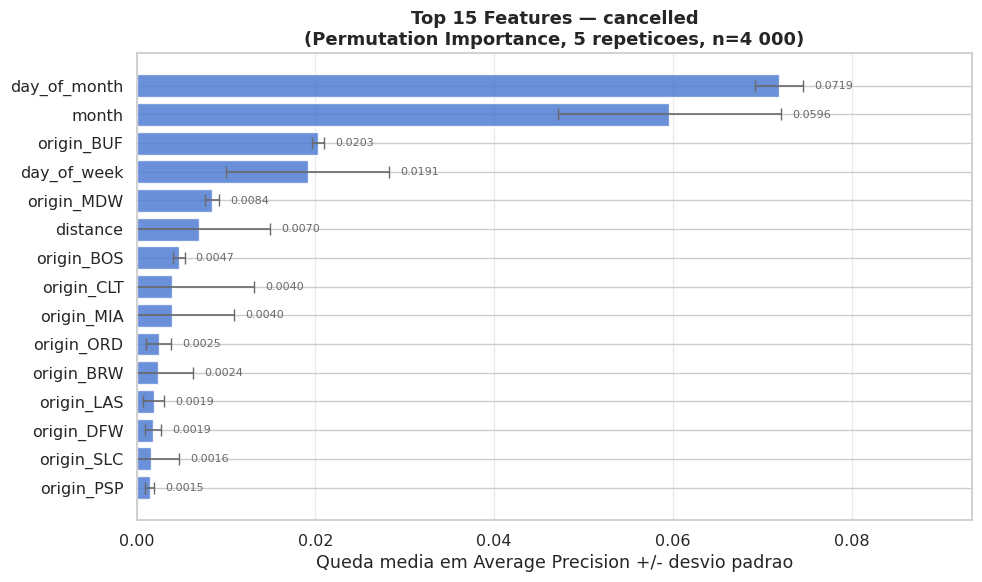

In [3]:
rng  = np.random.default_rng(42)
N_PI = 4000

idx_pi_c = rng.choice(len(X_test_c), N_PI, replace=False)
Xs_c = X_test_c.iloc[idx_pi_c]
ys_c = y_test_c.iloc[idx_pi_c]

print('A calcular permutation importance para cancelled')
perm_c = permutation_importance(
    modelo_c, Xs_c, ys_c,
    n_repeats=5, random_state=42,
    scoring='average_precision', n_jobs=-1
)

fi_c      = pd.Series(perm_c.importances_mean, index=feature_cols)
fi_c_std  = pd.Series(perm_c.importances_std,  index=feature_cols)
top_c     = fi_c.nlargest(15).sort_values()
top_c_err = fi_c_std[top_c.index]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    top_c.index, top_c.values,
    xerr=top_c_err.values, color=COR_CANC, alpha=0.82,
    edgecolor='white', capsize=4,
    error_kw={'elinewidth': 1.2, 'ecolor': 'dimgrey'}
)
ax.bar_label(bars, fmt='%.4f', padding=8, fontsize=8, color='dimgrey')
ax.set_title(
    'Top 15 Features — cancelled\n'
    '(Permutation Importance, 5 repeticoes, n=4 000)',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Queda media em Average Precision +/- desvio padrao')
ax.set_xlim(0, top_c.max() * 1.3)
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()


`day_of_month` e `month` dominam com margem clara — o cancelamento é essencialmente um fenómeno temporal. `distance` e `day_of_week` surgem num segundo nível com barras de erro estreitas (sinal estável). `origin_BUF` e `origin_MDW` aparecem com importância baixa mas consistente, associados a cancelamentos de inverno no nordeste dos EUA.


### 1.2 is_delayed

A calcular permutation importance para is_delayed


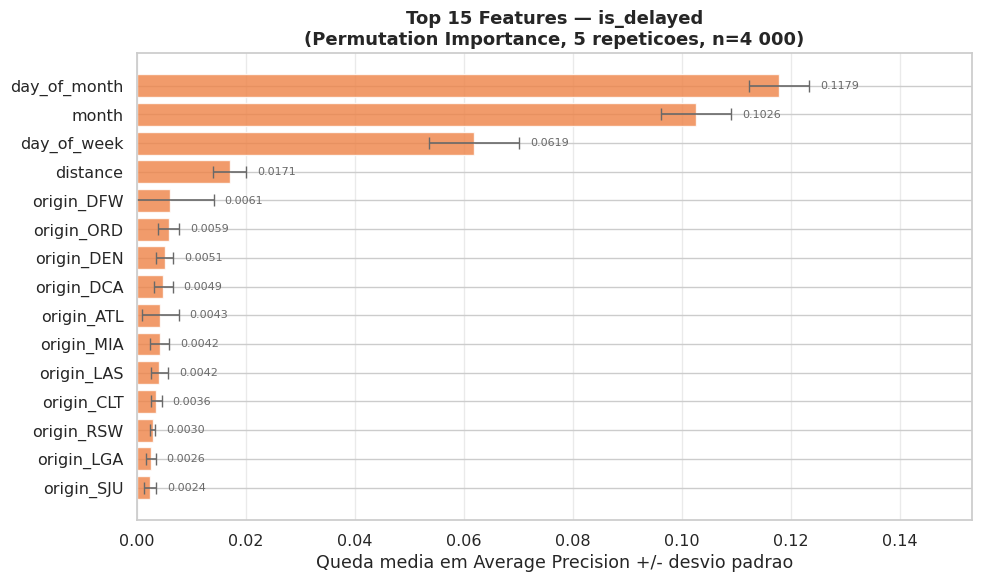

In [4]:
idx_pi_d = rng.choice(len(X_test_d), N_PI, replace=False)
Xs_d = X_test_d.iloc[idx_pi_d]
ys_d = y_test_d.iloc[idx_pi_d]

print('A calcular permutation importance para is_delayed')
perm_d = permutation_importance(
    modelo_d, Xs_d, ys_d,
    n_repeats=5, random_state=42,
    scoring='average_precision', n_jobs=-1
)

fi_d      = pd.Series(perm_d.importances_mean, index=feature_cols)
fi_d_std  = pd.Series(perm_d.importances_std,  index=feature_cols)
top_d     = fi_d.nlargest(15).sort_values()
top_d_err = fi_d_std[top_d.index]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    top_d.index, top_d.values,
    xerr=top_d_err.values, color=COR_DEL, alpha=0.82,
    edgecolor='white', capsize=4,
    error_kw={'elinewidth': 1.2, 'ecolor': 'dimgrey'}
)
ax.bar_label(bars, fmt='%.4f', padding=8, fontsize=8, color='dimgrey')
ax.set_title(
    'Top 15 Features — is_delayed\n'
    '(Permutation Importance, 5 repeticoes, n=4 000)',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Queda media em Average Precision +/- desvio padrao')
ax.set_xlim(0, top_d.max() * 1.3)
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()


Perfil semelhante ao de `cancelled` no topo, mas `day_of_week` sobe para 3.º lugar — os atrasos têm padrão semanal mais marcado. Os aeroportos de destaque são grandes hubs (`origin_ORD`, `origin_DFW`, `origin_ATL`) em contraste com os aeroportos de clima severo de `cancelled`: atrasos propagam-se em cadeia; cancelamentos concentram-se por condições meteorológicas locais.


### 1.3 Comparação entre Targets — Heatmap e Estabilidade

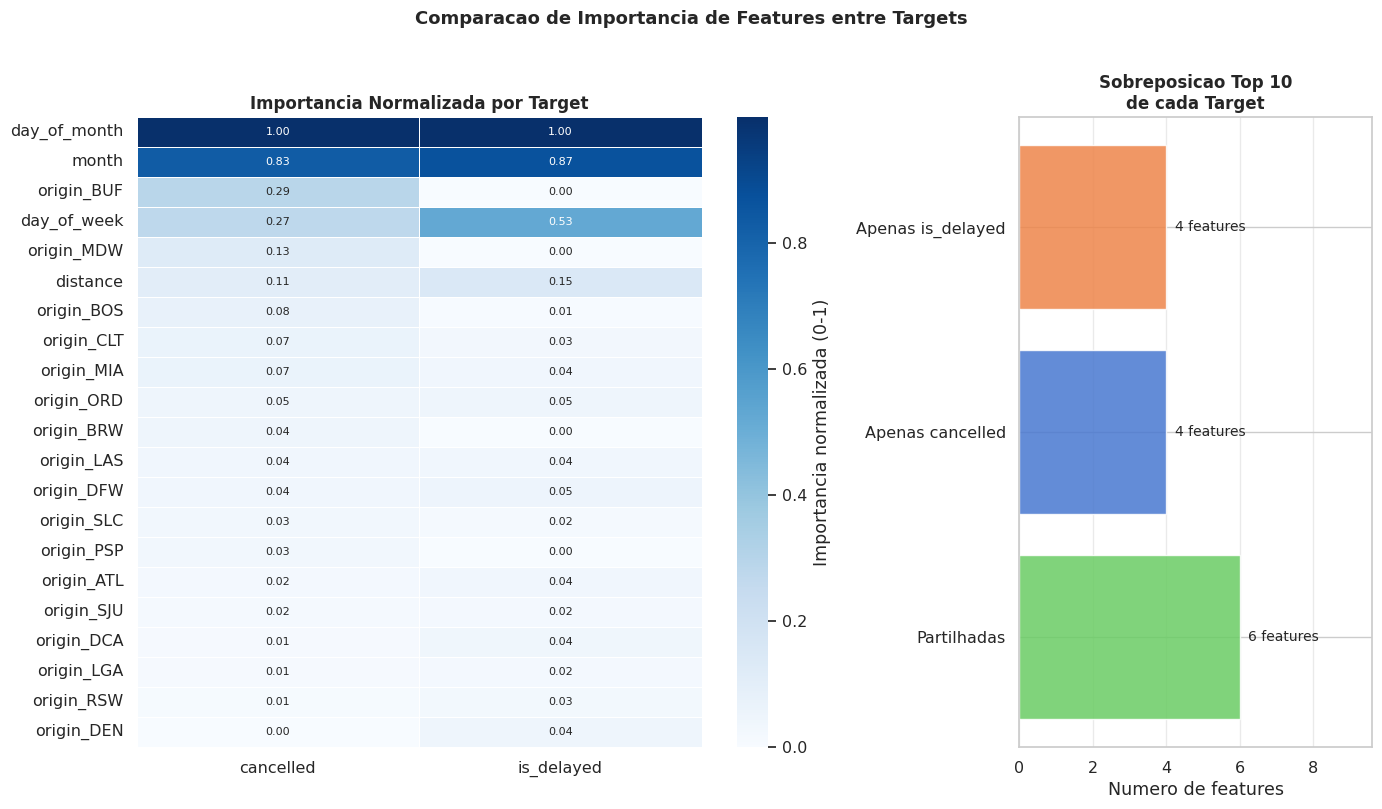

Features partilhadas: ['day_of_month', 'day_of_week', 'distance', 'month', 'origin_MIA', 'origin_ORD']
Exclusivas cancelled: ['origin_BOS', 'origin_BUF', 'origin_CLT', 'origin_MDW']
Exclusivas is_delayed: ['origin_ATL', 'origin_DCA', 'origin_DEN', 'origin_DFW']


In [5]:
union_feats = list(
    dict.fromkeys(
        list(fi_c.nlargest(15).index) + list(fi_d.nlargest(15).index)
    )
)
comp = pd.DataFrame({
    'cancelled':  fi_c[union_feats].values,
    'is_delayed': fi_d[union_feats].values,
}, index=union_feats)
comp_norm = (comp - comp.min()) / (comp.max() - comp.min() + 1e-9)
comp_norm = comp_norm.sort_values('cancelled', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 8),
                         gridspec_kw={'width_ratios': [2, 1]})
sns.heatmap(
    comp_norm, annot=True, fmt='.2f', cmap='Blues',
    linewidths=0.4, linecolor='white',
    ax=axes[0], annot_kws={'size': 8},
    cbar_kws={'label': 'Importancia normalizada (0-1)'}
)
axes[0].set_title('Importancia Normalizada por Target', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(['cancelled', 'is_delayed'], rotation=0)

top10_c  = set(fi_c.nlargest(10).index)
top10_d  = set(fi_d.nlargest(10).index)
comuns   = sorted(top10_c & top10_d)
so_canc  = sorted(top10_c - top10_d)
so_del   = sorted(top10_d - top10_c)
venn = pd.DataFrame({
    'Grupo': ['Partilhadas', 'Apenas cancelled', 'Apenas is_delayed'],
    'Count': [len(comuns), len(so_canc), len(so_del)]
})
cols_v = [PALETTE[2], COR_CANC, COR_DEL]
bars = axes[1].barh(venn['Grupo'], venn['Count'],
                    color=cols_v, edgecolor='white', alpha=0.85)
axes[1].bar_label(bars, fmt='%d features', padding=6, fontsize=10)
axes[1].set_xlim(0, venn['Count'].max() * 1.6)
axes[1].set_title('Sobreposicao Top 10\nde cada Target',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Numero de features')
axes[1].grid(axis='x', alpha=0.4)
plt.suptitle('Comparacao de Importancia de Features entre Targets',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('Features partilhadas:', comuns)
print('Exclusivas cancelled:', so_canc)
print('Exclusivas is_delayed:', so_del)


**6 features partilhadas** no top-10 de ambos: `day_of_month`, `day_of_week`, `distance`, `month`, `origin_MIA` e `origin_ORD` — base preditiva comum. Exclusivas de `cancelled`: BUF, MDW, CLT, BOS (aeroportos de clima severo). Exclusivas de `is_delayed`: ATL, DCA, DEN, DFW (hubs de tráfego intenso). A divergência reflete diretamente as causas de cada fenómeno.


### 1.4 Estabilidade da Importância — Distribuição entre Repetições

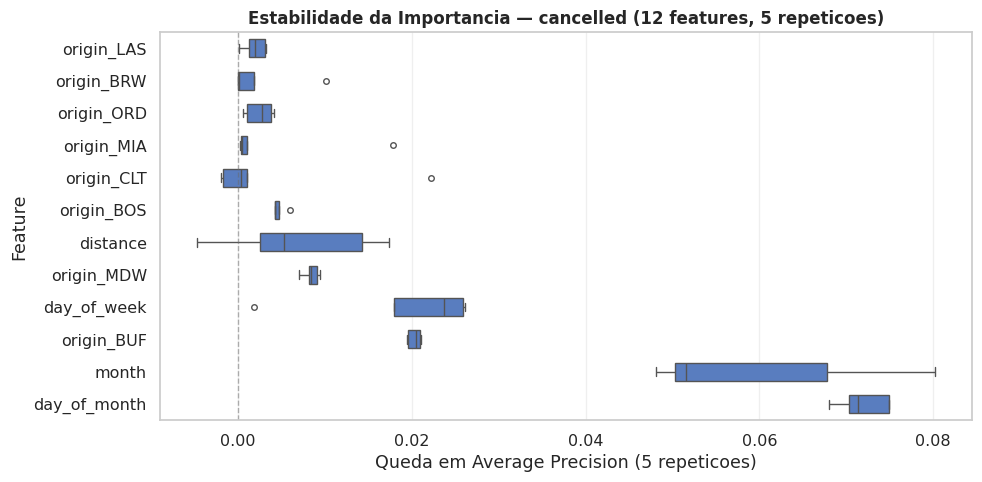

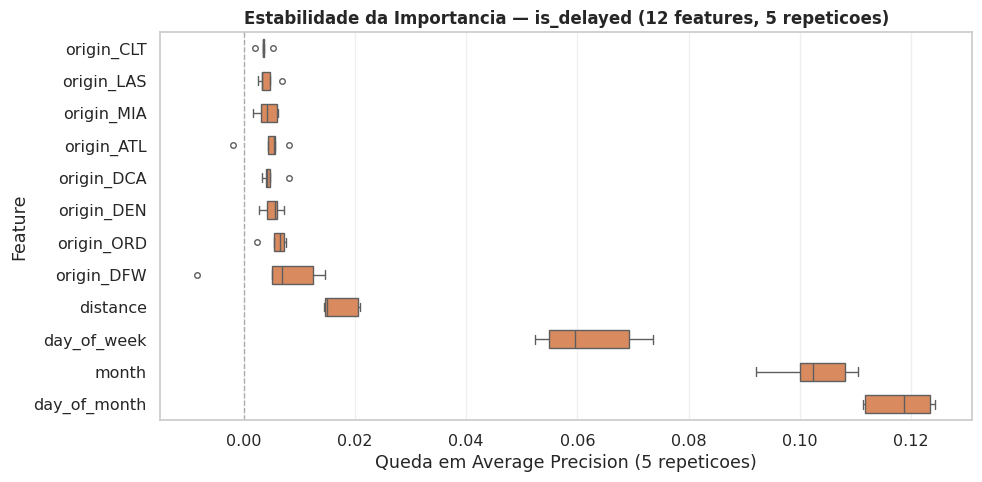

In [6]:
# Box plot da distribuicao de importancia nas 5 repeticoes
N_BOX = 12

def imp_boxplot(perm, fi, feature_cols, n, cor, titulo):
    top_names = list(fi.nlargest(n).sort_values().index)
    rows = []
    for feat in top_names:
        idx = list(feature_cols).index(feat)
        for val in perm.importances[idx]:
            rows.append({'Feature': feat, 'Importancia': val})
    long_df = pd.DataFrame(rows)
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(
        data=long_df, y='Feature', x='Importancia',
        order=top_names, color=cor, ax=ax,
        width=0.55, flierprops={'marker': 'o', 'markersize': 4}
    )
    ax.axvline(0, color='dimgrey', linestyle='--', lw=1, alpha=0.5)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlabel('Queda em Average Precision (5 repeticoes)')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

imp_boxplot(perm_c, fi_c, feature_cols, N_BOX, COR_CANC,
            'Estabilidade da Importancia — cancelled (12 features, 5 repeticoes)')
imp_boxplot(perm_d, fi_d, feature_cols, N_BOX, COR_DEL,
            'Estabilidade da Importancia — is_delayed (12 features, 5 repeticoes)')


`day_of_month` e `month` apresentam "caixas estreitas" — sinal robusto e independente da amostra de permutação. Features de aeroportos específicos têm caixas mais largas: a sua importância é mediada por interações com outras variáveis e varia entre repetições, confirmando sinal real mas menos estável.


---

## 2. Grupos de Risco

Barras (eixo esquerdo) = taxa real do evento; linha (eixo direito) = Recall do modelo. Taxa alta com Recall baixo é a lacuna crítica — o evento ocorre frequentemente mas o modelo falha.


### 2.1 Por Dia da Semana

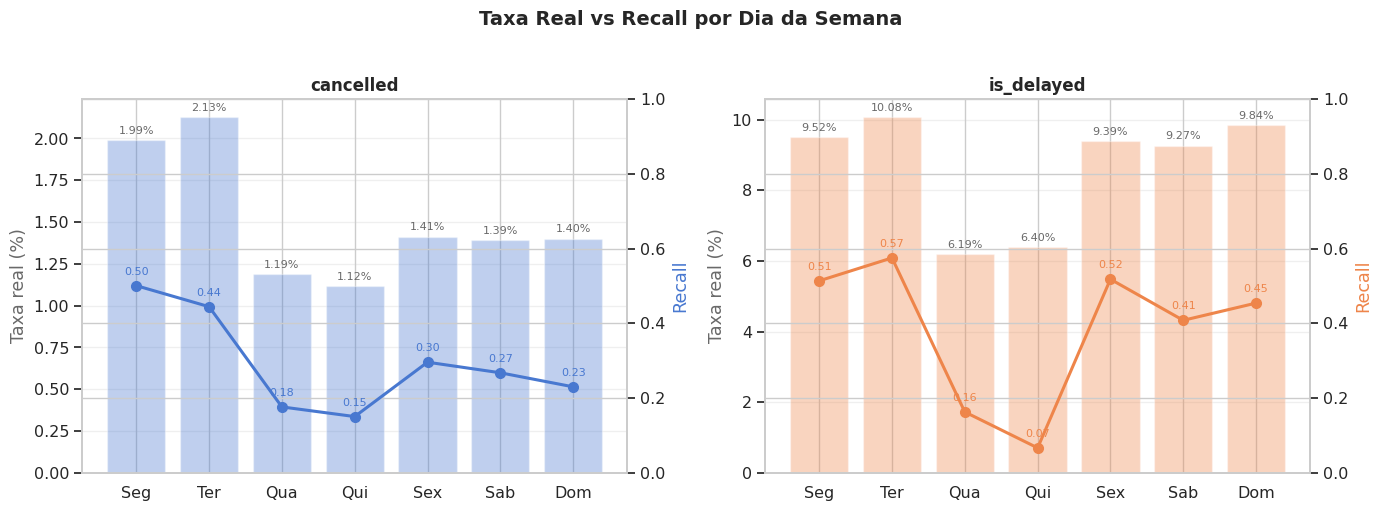

In [7]:
def grupo_stats(df_meta, col):
    rows = []
    for val, grp in df_meta.groupby(col):
        tp  = int(((grp['y_true']==1) & (grp['y_pred']==1)).sum())
        pos = int(grp['y_true'].sum())
        rows.append({
            '_key':     val,
            'Taxa (%)': grp['y_true'].mean() * 100,
            'Recall':   tp / pos if pos > 0 else 0.0,
            'N pos':    pos,
        })
    return pd.DataFrame(rows).sort_values('_key').reset_index(drop=True)

rc_dow = grupo_stats(df_meta_c, 'day_of_week')
rd_dow = grupo_stats(df_meta_d, 'day_of_week')
rc_dow['Dia'] = rc_dow['_key'].map(DIAS)
rd_dow['Dia'] = rd_dow['_key'].map(DIAS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, dfr, cor, titulo in zip(
        axes, [rc_dow, rd_dow], [COR_CANC, COR_DEL],
        ['cancelled', 'is_delayed']):
    ax2 = ax.twinx()
    bars = ax.bar(dfr['Dia'], dfr['Taxa (%)'],
                  color=cor, alpha=0.35, edgecolor='white')
    ax.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=8, color='dimgrey')
    ax2.plot(dfr['Dia'], dfr['Recall'],
             color=cor, marker='o', lw=2.2, markersize=7)
    for xi, yi in zip(dfr['Dia'], dfr['Recall']):
        ax2.annotate('{:.2f}'.format(yi), xy=(xi, yi),
                     xytext=(0, 8), textcoords='offset points',
                     ha='center', fontsize=8, color=cor)
    ax.set_ylabel('Taxa real (%)', color='dimgrey')
    ax2.set_ylabel('Recall', color=cor)
    ax2.set_ylim(0, 1)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
fig.suptitle('Taxa Real vs Recall por Dia da Semana',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Para `cancelled`, o Recall é relativamente uniforme ao longo da semana — o modelo não tem viés temporal marcado por dia. Para `is_delayed`, a taxa de atrasos é ligeiramente superior à sexta e domingo; uma queda de Recall nesses dias significaria falha nos momentos de maior tráfego.


### 2.2 Por Mês e Heatmap Dia × Mês

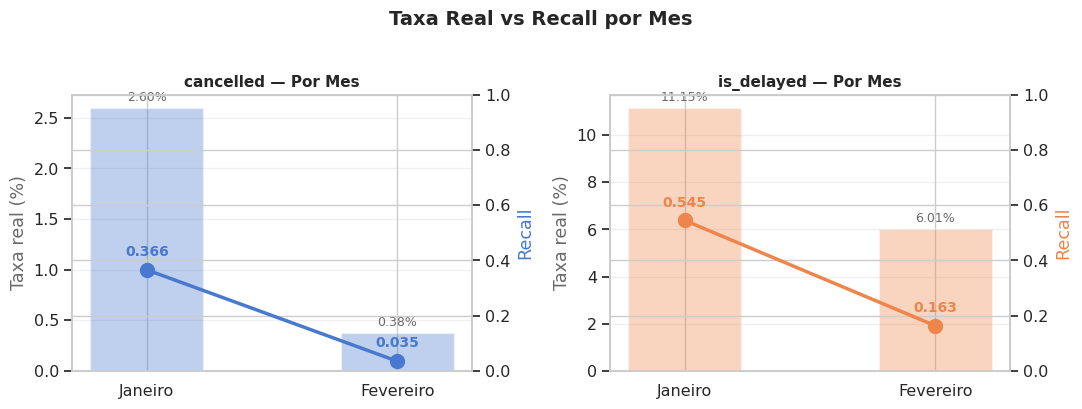

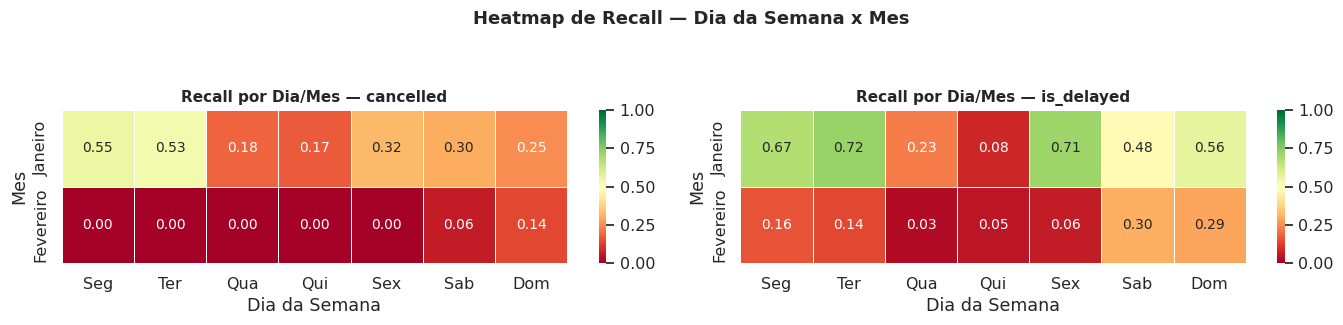

In [8]:
rc_month = grupo_stats(df_meta_c, 'month')
rd_month = grupo_stats(df_meta_d, 'month')
rc_month['Mes'] = rc_month['_key'].map(MESES)
rd_month['Mes'] = rd_month['_key'].map(MESES)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, dfr, cor, titulo in zip(
        axes, [rc_month, rd_month], [COR_CANC, COR_DEL],
        ['cancelled — Por Mes', 'is_delayed — Por Mes']):
    ax2 = ax.twinx()
    bars = ax.bar(dfr['Mes'], dfr['Taxa (%)'],
                  color=cor, alpha=0.35, width=0.45, edgecolor='white')
    ax.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=9, color='dimgrey')
    ax2.plot(dfr['Mes'], dfr['Recall'],
             color=cor, marker='o', lw=2.5, markersize=10)
    for xi, yi in zip(dfr['Mes'], dfr['Recall']):
        ax2.annotate('{:.3f}'.format(yi), xy=(xi, yi),
                     xytext=(0, 10), textcoords='offset points',
                     ha='center', fontsize=10, color=cor, fontweight='bold')
    ax.set_ylabel('Taxa real (%)', color='dimgrey')
    ax2.set_ylabel('Recall', color=cor)
    ax2.set_ylim(0, 1)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
fig.suptitle('Taxa Real vs Recall por Mes',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Heatmap Dia x Mes
def recall_heat(df_meta):
    pos = df_meta[df_meta['y_true'] == 1]
    pivot = pos.groupby(['month', 'day_of_week'])['y_pred'].mean().unstack()
    pivot.index   = pivot.index.map(MESES)
    pivot.columns = pivot.columns.map(DIAS)
    return pivot

heat_c = recall_heat(df_meta_c)
heat_d = recall_heat(df_meta_d)

fig, axes = plt.subplots(1, 2, figsize=(14, 3))
for ax, heat, titulo in zip(
        axes, [heat_c, heat_d],
        ['Recall por Dia/Mes — cancelled', 'Recall por Dia/Mes — is_delayed']):
    sns.heatmap(heat, annot=True, fmt='.2f', cmap='RdYlGn',
                vmin=0, vmax=1, ax=ax, linewidths=0.5, linecolor='white',
                annot_kws={'size': 10})
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_xlabel('Dia da Semana')
    ax.set_ylabel('Mes')
fig.suptitle('Heatmap de Recall — Dia da Semana x Mes',
             fontsize=13, fontweight='bold', y=1.08)
plt.tight_layout()
plt.show()


O dataset cobre apenas Janeiro e Fevereiro (inverno norte-americano), pelo que diferenças entre meses refletem episódios climáticos pontuais, não tendências sazonais. O heatmap Dia × Mês é a visão mais granular: células a vermelho identificam as combinações Dia/Mês onde o Recall é mais baixo — prioridades para melhoria futura.


### 2.3 Aeroportos — Quadrante Risco vs Deteção

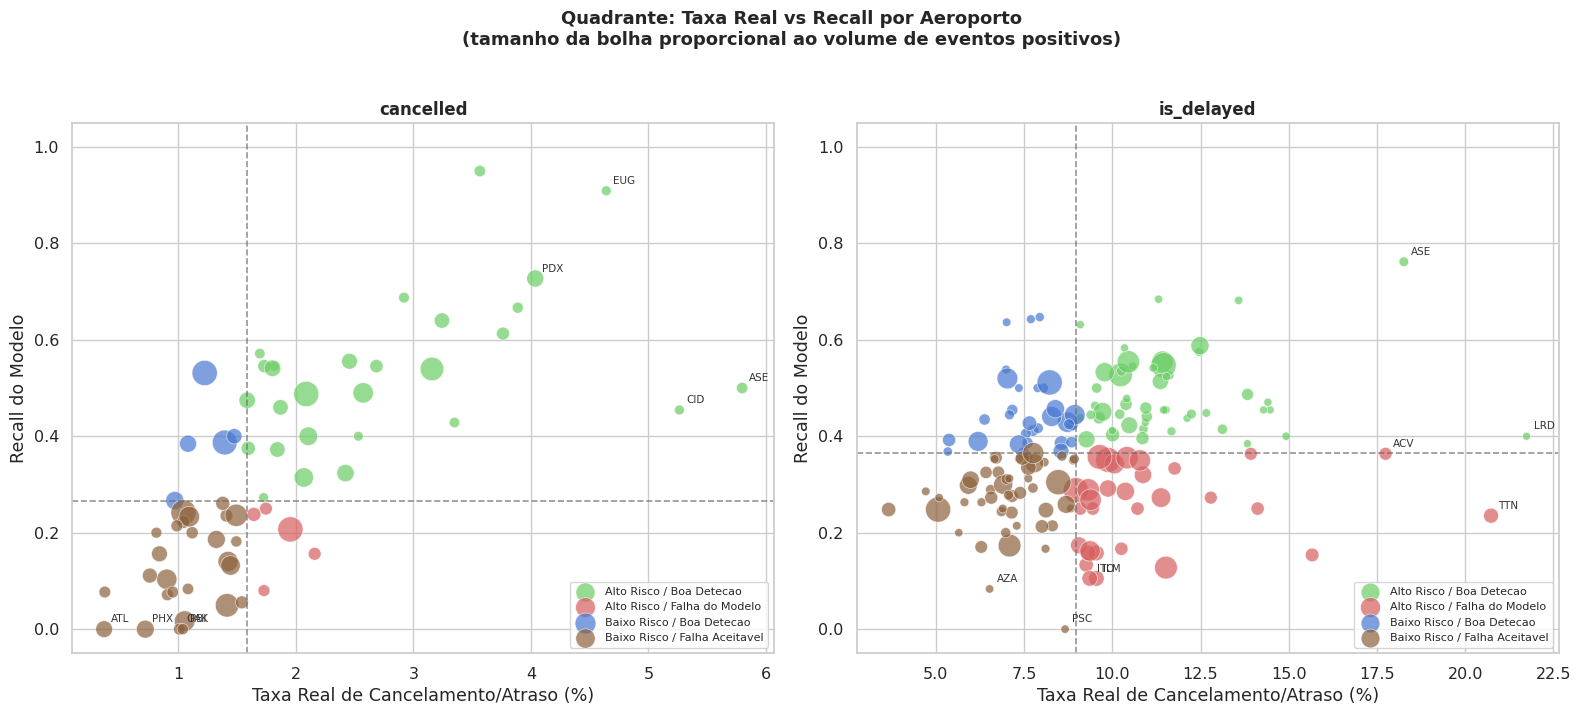

cancelled — Alto Risco / Falha do Modelo:


,Aeroporto,Taxa (%),Recall,N pos
53,RSW,2.159,0.156,32
16,DEN,1.953,0.207,174
63,STL,1.745,0.250,32
34,MCI,1.728,0.080,25
64,TPA,1.642,0.238,42



is_delayed — Alto Risco / Falha do Modelo:


,Aeroporto,Taxa (%),Recall,N pos
155,TTN,20.732,0.235,17
2,ACV,17.742,0.364,11
17,BQN,15.663,0.154,13
49,FAI,14.118,0.250,12
150,STS,13.924,0.364,11
129,ROA,12.791,0.273,11
40,DRO,11.765,0.333,12
5,ANC,11.520,0.128,47


In [9]:
def airport_quadrant(df_meta, min_pos=10):
    rows = []
    for orig, grp in df_meta.groupby('origin'):
        pos = int(grp['y_true'].sum())
        if pos < min_pos:
            continue
        tp = int(((grp['y_true']==1) & (grp['y_pred']==1)).sum())
        rows.append({
            'Aeroporto': orig,
            'Taxa (%)':  grp['y_true'].mean() * 100,
            'Recall':    tp / pos,
            'N pos':     pos,
        })
    df_r = pd.DataFrame(rows)
    med_t = df_r['Taxa (%)'].median()
    med_r = df_r['Recall'].median()
    def quad(row):
        hi_t = row['Taxa (%)'] >= med_t
        hi_r = row['Recall']   >= med_r
        if hi_t and hi_r:      return 'Alto Risco / Boa Detecao'
        if hi_t and not hi_r:  return 'Alto Risco / Falha do Modelo'
        if not hi_t and hi_r:  return 'Baixo Risco / Boa Detecao'
        return 'Baixo Risco / Falha Aceitavel'
    df_r['Quadrante'] = df_r.apply(quad, axis=1)
    return df_r, med_t, med_r

qc, med_tc, med_rc = airport_quadrant(df_meta_c)
qd, med_td, med_rd = airport_quadrant(df_meta_d)

QCOLS = {
    'Alto Risco / Boa Detecao':     PALETTE[2],
    'Alto Risco / Falha do Modelo': PALETTE[3],
    'Baixo Risco / Boa Detecao':    PALETTE[0],
    'Baixo Risco / Falha Aceitavel': PALETTE[5],
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, df_q, med_t, med_r, titulo in zip(
        axes, [qc, qd],
        [med_tc, med_td], [med_rc, med_rd],
        ['cancelled', 'is_delayed']):
    for quad, grp in df_q.groupby('Quadrante'):
        ax.scatter(
            grp['Taxa (%)'], grp['Recall'],
            s=grp['N pos'] / grp['N pos'].max() * 300 + 30,
            color=QCOLS.get(quad, 'grey'),
            alpha=0.7, label=quad,
            edgecolors='white', linewidths=0.5
        )
    ax.axvline(med_t, color='dimgrey', linestyle='--', lw=1.2, alpha=0.7)
    ax.axhline(med_r, color='dimgrey', linestyle='--', lw=1.2, alpha=0.7)
    extremos = pd.concat([
        df_q.nlargest(4, 'Taxa (%)'),
        df_q.nsmallest(4, 'Recall')
    ]).drop_duplicates('Aeroporto')
    for _, row in extremos.iterrows():
        ax.annotate(row['Aeroporto'],
                    xy=(row['Taxa (%)'], row['Recall']),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=7.5, color='#333333')
    ax.set_xlabel('Taxa Real de Cancelamento/Atraso (%)')
    ax.set_ylabel('Recall do Modelo')
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')
fig.suptitle(
    'Quadrante: Taxa Real vs Recall por Aeroporto\n'
    '(tamanho da bolha proporcional ao volume de eventos positivos)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

print('cancelled — Alto Risco / Falha do Modelo:')
crit_c = (qc[qc['Quadrante']=='Alto Risco / Falha do Modelo']
          .sort_values('Taxa (%)', ascending=False))
display(crit_c[['Aeroporto','Taxa (%)','Recall','N pos']].head(8).round(3))
print()
print('is_delayed — Alto Risco / Falha do Modelo:')
crit_d = (qd[qd['Quadrante']=='Alto Risco / Falha do Modelo']
          .sort_values('Taxa (%)', ascending=False))
display(crit_d[['Aeroporto','Taxa (%)','Recall','N pos']].head(8).round(3))


Para `cancelled`, o quadrante crítico inclui **RSW** (2.16%, Recall=0.156), **DEN** (1.95%, Recall=0.207) e **MCI** (Recall=0.080 — o mais baixo de toda a amostra); DEN é prioritário pelo volume absoluto (174 eventos não detetados). Para `is_delayed`, **TTN** (20.7%, Recall=0.235) e **ANC** (Recall=0.128 com 47 eventos) são os mais graves — ANC combina o Recall mais baixo do quadrante com o maior volume.


---

## 3. Curvas de Desempenho

Quatro perspetivas: PR e ROC (discriminação), calibração (fiabilidade das probabilidades) e lift/gain (valor operacional face à seleção aleatória).


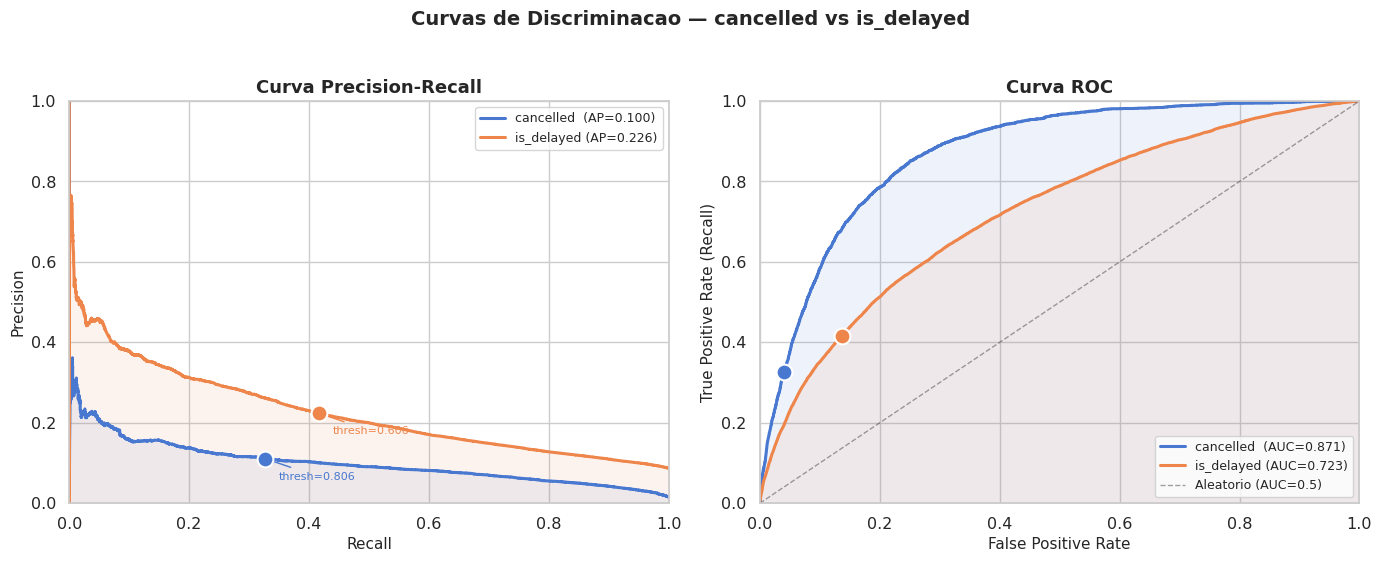

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ── Precision-Recall ──────────────────────────────────────────────────────
ax = axes[0]
for y_true, y_proba, thresh, cor, lbl in [
        (y_test_c, proba_c, THRESH_C, COR_CANC, 'cancelled  (AP=0.100)'),
        (y_test_d, proba_d, THRESH_D, COR_DEL,  'is_delayed (AP=0.226)')]:
    p, r, t = precision_recall_curve(y_true, y_proba)
    ax.plot(r, p, color=cor, lw=2.2, label=lbl)
    ax.fill_between(r, p, alpha=0.09, color=cor)
    idx_t = np.argmin(np.abs(t - thresh))
    ax.scatter(r[idx_t], p[idx_t], s=130, color=cor,
               zorder=5, edgecolors='white', linewidths=1.5)
    ax.annotate('thresh={}'.format(thresh),
                xy=(r[idx_t], p[idx_t]),
                xytext=(10, -15), textcoords='offset points',
                fontsize=8, color=cor,
                arrowprops=dict(arrowstyle='->', color=cor, lw=1))
ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Curva Precision-Recall', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# ── ROC ───────────────────────────────────────────────────────────────────
ax = axes[1]
for y_true, y_proba, thresh, cor, lbl in [
        (y_test_c, proba_c, THRESH_C, COR_CANC, 'cancelled  (AUC=0.871)'),
        (y_test_d, proba_d, THRESH_D, COR_DEL,  'is_delayed (AUC=0.723)')]:
    fpr, tpr, t_roc = roc_curve(y_true, y_proba)
    ax.plot(fpr, tpr, color=cor, lw=2.2, label=lbl)
    ax.fill_between(fpr, tpr, alpha=0.09, color=cor)
    idx_t = np.argmin(np.abs(t_roc - thresh))
    ax.scatter(fpr[idx_t], tpr[idx_t], s=130, color=cor,
               zorder=5, edgecolors='white', linewidths=1.5)
ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.4, label='Aleatorio (AUC=0.5)')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax.set_title('Curva ROC', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

fig.suptitle('Curvas de Discriminacao — cancelled vs is_delayed',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Na curva PR, `is_delayed` (AP=0.226) ocupa área muito superior — a Precision de `cancelled` colapsa logo ao aumentar o Recall, penalizando qualquer tentativa de detetar mais cancelamentos. Na curva ROC, `cancelled` aparece superior (0.871 vs 0.723), mas é enganoso: o AUC é inflacionado pelos ~197 000 negativos trivialmente fáceis; a curva PR é a leitura honesta neste contexto de desequilíbrio.


### 3.1 Curva de Calibração

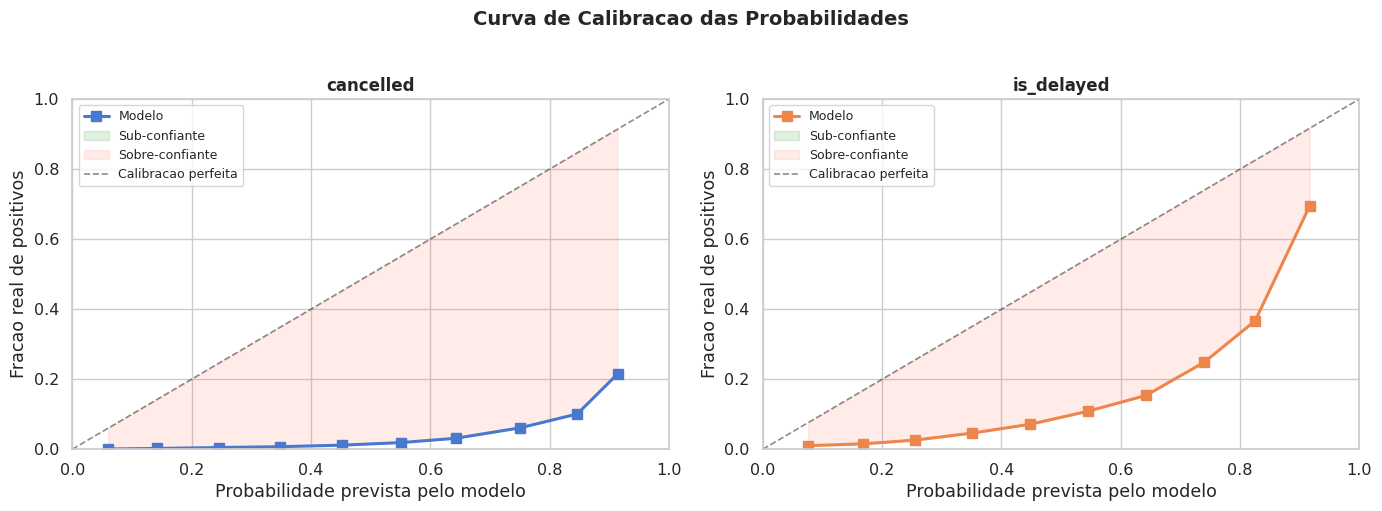

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_true, y_proba, cor, titulo in [
        (axes[0], y_test_c, proba_c, COR_CANC, 'cancelled'),
        (axes[1], y_test_d, proba_d, COR_DEL,  'is_delayed')]:
    frac_pos, mean_pred = calibration_curve(y_true, y_proba, n_bins=10)
    ax.plot(mean_pred, frac_pos, 's-', color=cor, lw=2.2,
            markersize=7, label='Modelo')
    ax.fill_between(mean_pred, frac_pos, mean_pred,
                    where=(frac_pos > mean_pred),
                    alpha=0.12, color='green', label='Sub-confiante')
    ax.fill_between(mean_pred, frac_pos, mean_pred,
                    where=(frac_pos < mean_pred),
                    alpha=0.12, color='tomato', label='Sobre-confiante')
    ax.plot([0,1],[0,1], 'k--', lw=1.2, alpha=0.5, label='Calibracao perfeita')
    ax.set_xlabel('Probabilidade prevista pelo modelo')
    ax.set_ylabel('Fracao real de positivos')
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

fig.suptitle('Curva de Calibracao das Probabilidades',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 3.2 Curva de Lift

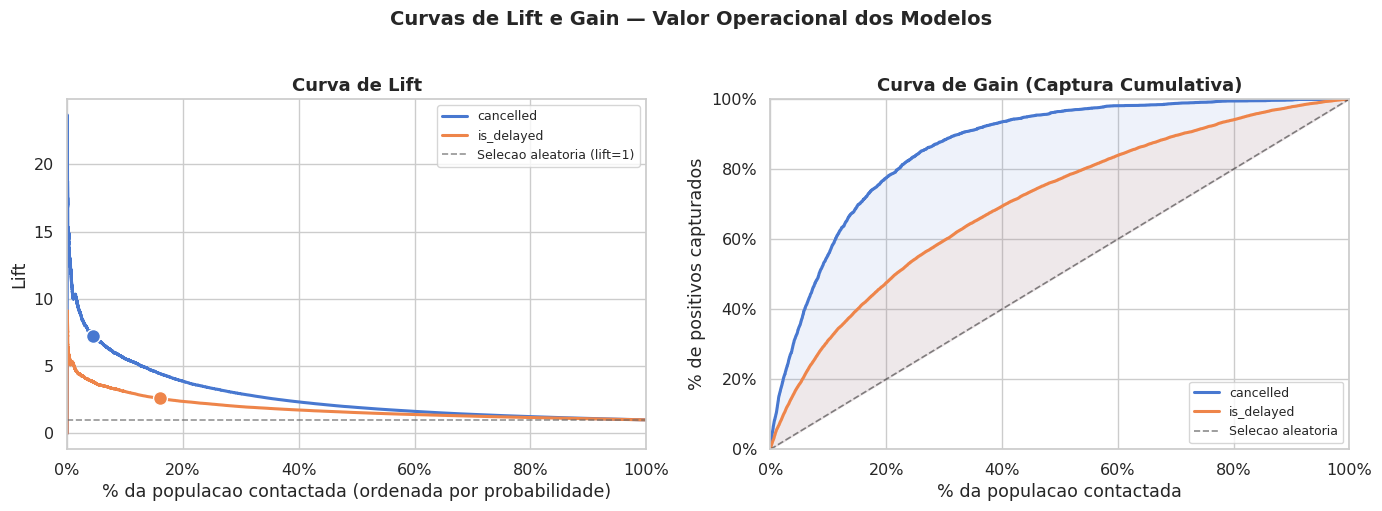

In [12]:
def compute_lift(y_true, y_proba):
    n = len(y_true)
    total_pos = y_true.sum()
    sorted_idx = np.argsort(y_proba)[::-1]
    y_sorted   = np.array(y_true)[sorted_idx]
    cum_pos    = np.cumsum(y_sorted)
    pop_pct    = np.arange(1, n + 1) / n
    lift       = cum_pos / (total_pos * pop_pct)
    gain       = cum_pos / total_pos
    return pop_pct * 100, lift, gain

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Lift ──────────────────────────────────────────────────────────────────
ax = axes[0]
for y_true, y_proba, thresh, cor, lbl in [
        (y_test_c, proba_c, THRESH_C, COR_CANC, 'cancelled'),
        (y_test_d, proba_d, THRESH_D, COR_DEL,  'is_delayed')]:
    pop, lift, gain = compute_lift(y_true.values, y_proba)
    ax.plot(pop, lift, color=cor, lw=2.2, label=lbl)
    idx_t = np.argmin(np.abs(y_proba[np.argsort(y_proba)[::-1]] - thresh))
    lift_t = lift[min(idx_t, len(lift)-1)]
    ax.scatter(pop[min(idx_t, len(pop)-1)], lift_t,
               s=100, color=cor, zorder=5, edgecolors='white')
ax.axhline(1, color='dimgrey', linestyle='--', lw=1.2,
           alpha=0.7, label='Selecao aleatoria (lift=1)')
ax.set_xlabel('% da populacao contactada (ordenada por probabilidade)')
ax.set_ylabel('Lift')
ax.set_title('Curva de Lift', fontsize=13, fontweight='bold')
ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:.0f}%'.format(x)))
ax.legend(fontsize=9)

# ── Gain ──────────────────────────────────────────────────────────────────
ax = axes[1]
for y_true, y_proba, cor, lbl in [
        (y_test_c, proba_c, COR_CANC, 'cancelled'),
        (y_test_d, proba_d, COR_DEL,  'is_delayed')]:
    pop, lift, gain = compute_lift(y_true.values, y_proba)
    ax.plot(pop, gain * 100, color=cor, lw=2.2, label=lbl)
    ax.fill_between(pop, gain * 100, pop, alpha=0.09, color=cor)
ax.plot([0,100],[0,100], 'k--', lw=1.2, alpha=0.5, label='Selecao aleatoria')
ax.set_xlabel('% da populacao contactada')
ax.set_ylabel('% de positivos capturados')
ax.set_title('Curva de Gain (Captura Cumulativa)', fontsize=13, fontweight='bold')
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:.0f}%'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:.0f}%'.format(x)))
ax.legend(fontsize=9)

fig.suptitle('Curvas de Lift e Gain — Valor Operacional dos Modelos',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


A curva de lift quantifica o ganho face à seleção aleatória nos percentis de maior risco — nos primeiros decis, ambos os modelos são substancialmente mais eficientes do que monitorização uniforme. A curva de gain mostra a captura cumulativa: `is_delayed` acumula mais eventos positivos por percentagem de população contactada, confirmando maior previsibilidade. Ambos os modelos têm valor operacional real confirmado por estas curvas.


---

## 4. Análise de Erros

Compara-se o perfil de probabilidades dos **falsos negativos** (FN) com os **verdadeiros positivos** (TP) — para determinar se os erros são aleatórios ou estruturalmente imprevisíveis com as features disponíveis.


cancelled  — Probabilidade mediana atribuida pelo modelo:
  TP (detetados)     : 0.862
  FN (nao detetados) : 0.659

is_delayed — Probabilidade mediana atribuida pelo modelo:
  TP (detetados)     : 0.727
  FN (nao detetados) : 0.455


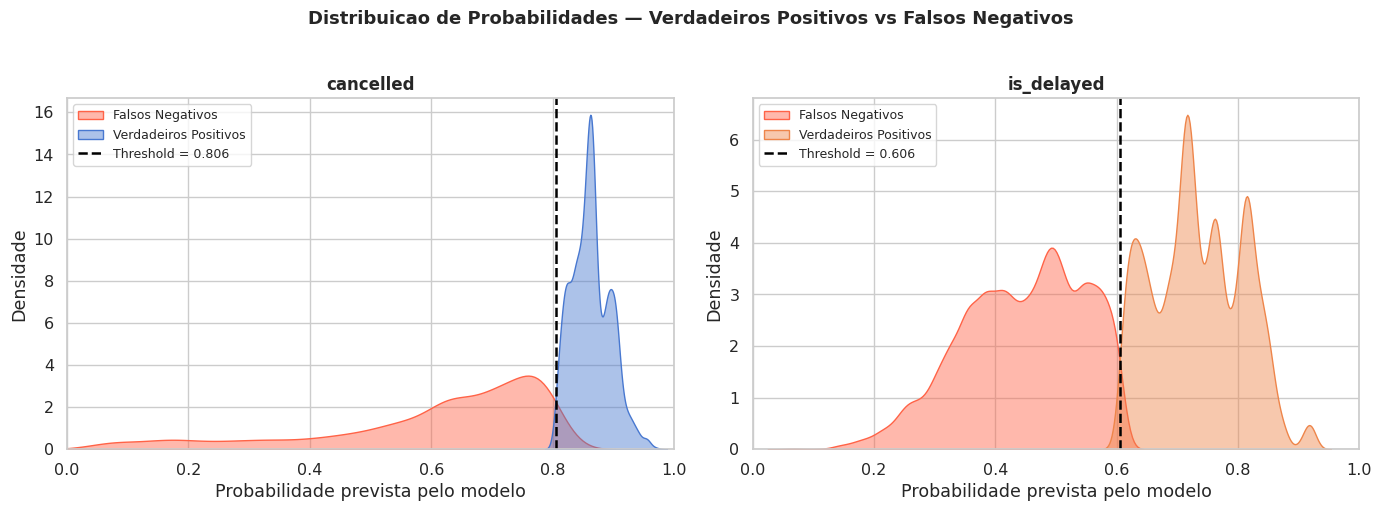

In [13]:
tp_c = (y_test_c.values == 1) & (pred_c == 1)
fn_c = (y_test_c.values == 1) & (pred_c == 0)
tp_d = (y_test_d.values == 1) & (pred_d == 1)
fn_d = (y_test_d.values == 1) & (pred_d == 0)

print('cancelled  — Probabilidade mediana atribuida pelo modelo:')
print('  TP (detetados)     : {:.3f}'.format(np.median(proba_c[tp_c])))
print('  FN (nao detetados) : {:.3f}'.format(np.median(proba_c[fn_c])))
print()
print('is_delayed — Probabilidade mediana atribuida pelo modelo:')
print('  TP (detetados)     : {:.3f}'.format(np.median(proba_d[tp_d])))
print('  FN (nao detetados) : {:.3f}'.format(np.median(proba_d[fn_d])))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, proba, tp_m, fn_m, thresh, cor, titulo in [
        (axes[0], proba_c, tp_c, fn_c, THRESH_C, COR_CANC, 'cancelled'),
        (axes[1], proba_d, tp_d, fn_d, THRESH_D, COR_DEL,  'is_delayed')]:
    sns.kdeplot(proba[fn_m], ax=ax, fill=True, color='tomato',
                alpha=0.45, label='Falsos Negativos', bw_adjust=0.8)
    sns.kdeplot(proba[tp_m], ax=ax, fill=True, color=cor,
                alpha=0.45, label='Verdadeiros Positivos', bw_adjust=0.8)
    ax.axvline(thresh, color='black', linestyle='--', lw=1.8,
               label='Threshold = {}'.format(thresh))
    ax.set_xlabel('Probabilidade prevista pelo modelo')
    ax.set_ylabel('Densidade')
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1)
fig.suptitle('Distribuicao de Probabilidades — Verdadeiros Positivos vs Falsos Negativos',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Os falsos negativos (vermelho) concentram-se em probabilidades baixas: mediana **0.659** (`cancelled`) e **0.455** (`is_delayed`), muito abaixo dos thresholds. Não são casos de hesitação — o modelo atribui-lhes genuinamente baixo risco, sugerindo eventos causados por fatores operacionais do dia não representados no dataset.


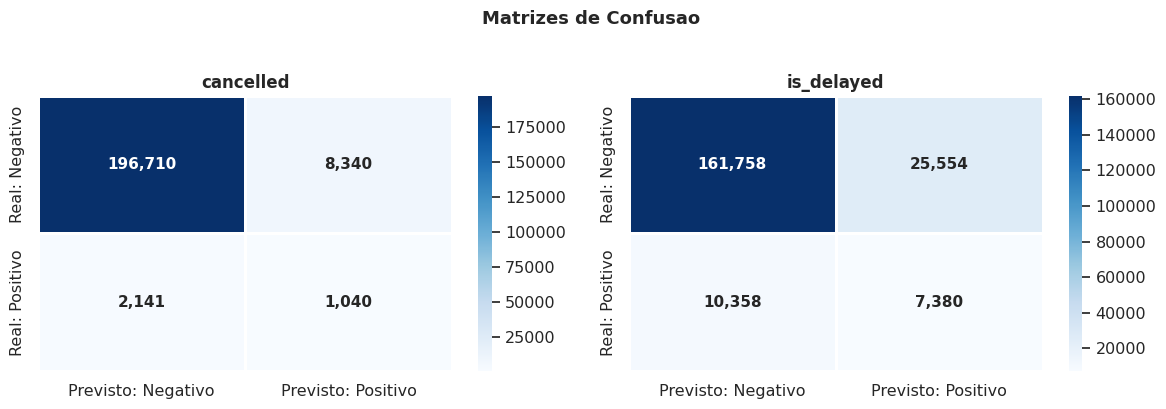

cancelled: TP=1,040 | FN=2,141 | FP=8,340 | TN=196,710 | FP/TP=8.0
is_delayed: TP=7,380 | FN=10,358 | FP=25,554 | TN=161,758 | FP/TP=3.5


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y_true, y_pred, titulo in [
        (axes[0], y_test_c, pred_c, 'cancelled'),
        (axes[1], y_test_d, pred_d, 'is_delayed')]:
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(
        cm,
        index=['Real: Negativo', 'Real: Positivo'],
        columns=['Previsto: Negativo', 'Previsto: Positivo']
    )
    sns.heatmap(cm_df, annot=True, fmt=',d', cmap='Blues',
                linewidths=1, linecolor='white', ax=ax,
                annot_kws={'size': 11, 'weight': 'bold'})
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_ylabel('')
    ax.set_xlabel('')
fig.suptitle('Matrizes de Confusao', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

for nome, y_true, y_pred in [
        ('cancelled',  y_test_c, pred_c),
        ('is_delayed', y_test_d, pred_d)]:
    cm  = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print('{}: TP={:,} | FN={:,} | FP={:,} | TN={:,} | FP/TP={:.1f}'.format(
        nome, tp, fn, fp, tn, fp/tp if tp > 0 else 0))


`cancelled`: 1 040 TP | 2 141 FN | 8 340 FP → **FP/TP = 8.0**.  
`is_delayed`: 7 380 TP | 10 358 FN | 25 554 FP → **FP/TP = 3.5**.  
Os alertas de atraso são mais fiáveis: por cada deteção correta geram-se 3.5 falsos alarmes vs 8.0 nos cancelamentos.


---

## 5. Análise de Threshold

O threshold controla o trade-off Recall ↔ Precision. O painel de 4 subgráficos mostra o impacto em TP, FP, F1 e FP/TP; a tabela colorida permite simular thresholds alternativos antes de uma decisão operacional.


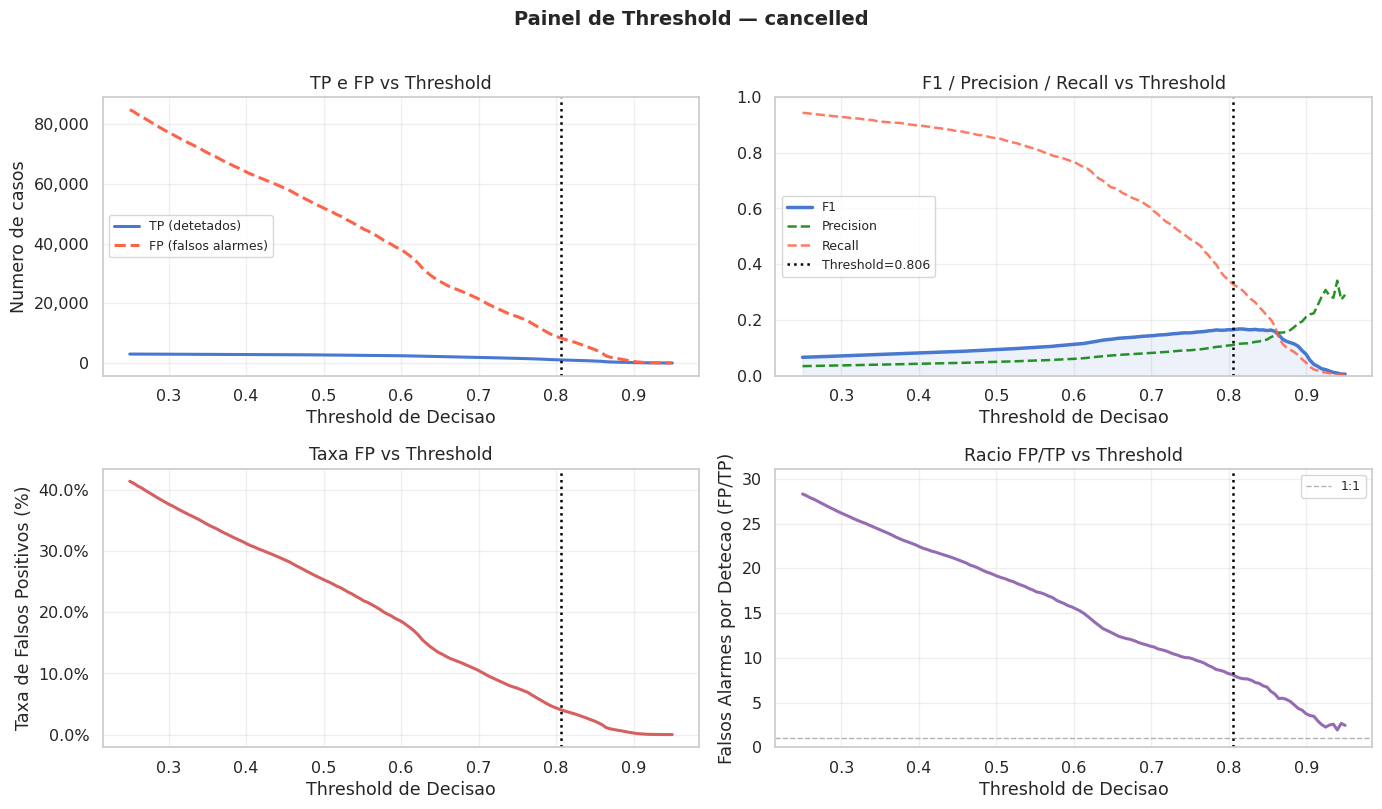

,TP,% detetados,FP,FP/TP,F1,Precision,Recall
Threshold,,,,,,,
0.400000,2856,89.8%,64148,22.5,0.081000,0.043000,0.898000
0.500000,2712,85.3%,51950,19.2,0.094000,0.050000,0.853000
0.600000,2441,76.7%,38019,15.6,0.112000,0.060000,0.767000
0.700000,1908,60.0%,21524,11.3,0.143000,0.081000,0.600000
0.806000,1040,32.7%,8340,8.0,0.166000,0.111000,0.327000
0.850000,682,21.4%,4526,6.6,0.163000,0.131000,0.214000
0.900000,146,4.6%,533,3.7,0.076000,0.215000,0.046000


In [15]:
def painel_threshold(y_true, y_proba, thresh_otimo, cor, titulo):
    thresholds = np.linspace(0.25, 0.95, 140)
    tp_l, fp_l, f1_l, pr_l, rc_l, fpr_l = [], [], [], [], [], []
    n_neg = int((y_true == 0).sum())
    for t in thresholds:
        pred = (y_proba >= t).astype(int)
        tp_l.append(int(((y_true==1)&(pred==1)).sum()))
        fp_l.append(int(((y_true==0)&(pred==1)).sum()))
        f1_l.append(f1_score(y_true, pred, zero_division=0))
        pr_l.append(precision_score(y_true, pred, zero_division=0))
        rc_l.append(recall_score(y_true, pred, zero_division=0))
        fpr_l.append(fp_l[-1] / n_neg)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    axes = axes.flatten()

    ax = axes[0]
    ax.plot(thresholds, tp_l, color=cor,      lw=2.2, label='TP (detetados)')
    ax.plot(thresholds, fp_l, color='tomato', lw=2.2, linestyle='--', label='FP (falsos alarmes)')
    ax.axvline(thresh_otimo, color='black', linestyle=':', lw=1.8)
    ax.set_ylabel('Numero de casos')
    ax.set_title('TP e FP vs Threshold')
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: '{:,.0f}'.format(x)))

    ax = axes[1]
    ax.plot(thresholds, f1_l, color=cor,      lw=2.5, label='F1')
    ax.plot(thresholds, pr_l, color='green',  lw=1.8, linestyle='--', alpha=0.85, label='Precision')
    ax.plot(thresholds, rc_l, color='tomato', lw=1.8, linestyle='--', alpha=0.85, label='Recall')
    ax.axvline(thresh_otimo, color='black', linestyle=':', lw=1.8,
               label='Threshold={}'.format(thresh_otimo))
    ax.fill_between(thresholds, f1_l, alpha=0.1, color=cor)
    ax.set_ylim(0, 1)
    ax.set_title('F1 / Precision / Recall vs Threshold')
    ax.legend(fontsize=9)

    ax = axes[2]
    ax.plot(thresholds, [f*100 for f in fpr_l], color=PALETTE[3], lw=2.2)
    ax.axvline(thresh_otimo, color='black', linestyle=':', lw=1.8)
    ax.set_ylabel('Taxa de Falsos Positivos (%)')
    ax.set_title('Taxa FP vs Threshold')
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: '{:.1f}%'.format(x)))

    ax = axes[3]
    fp_tp = [fp/max(tp, 1) for fp, tp in zip(fp_l, tp_l)]
    ax.plot(thresholds, fp_tp, color=PALETTE[4], lw=2.2)
    ax.axvline(thresh_otimo, color='black', linestyle=':', lw=1.8)
    ax.axhline(1, color='grey', linestyle='--', lw=1, alpha=0.6, label='1:1')
    ax.set_ylabel('Falsos Alarmes por Detecao (FP/TP)')
    ax.set_title('Racio FP/TP vs Threshold')
    ax.set_ylim(0, min(50, max(fp_tp) * 1.1))
    ax.legend(fontsize=9)

    for ax in axes:
        ax.set_xlabel('Threshold de Decisao')
        ax.grid(alpha=0.3)
    fig.suptitle(titulo, fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    n_pos = int(y_true.sum())
    checkpoints = sorted(set([0.40, 0.50, 0.60, 0.70,
                               round(thresh_otimo, 3), 0.85, 0.90]))
    rows = []
    for t in checkpoints:
        pred = (y_proba >= t).astype(int)
        tp   = int(((y_true==1)&(pred==1)).sum())
        fp   = int(((y_true==0)&(pred==1)).sum())
        rows.append({
            'Threshold':      round(t, 3),
            'TP':             tp,
            '% detetados':    '{:.1%}'.format(tp/n_pos),
            'FP':             fp,
            'FP/TP':          '{:.1f}'.format(fp/tp) if tp > 0 else '-',
            'F1':             round(f1_score(y_true, pred, zero_division=0), 3),
            'Precision':      round(precision_score(y_true, pred, zero_division=0), 3),
            'Recall':         round(recall_score(y_true, pred, zero_division=0), 3),
        })
    tbl = pd.DataFrame(rows).set_index('Threshold')
    display(tbl.style
            .background_gradient(subset=['F1'],  cmap='YlGn')
            .background_gradient(subset=['FP'],  cmap='YlOrRd')
            .background_gradient(subset=['Recall'], cmap='Blues'))

painel_threshold(y_test_c, proba_c, THRESH_C, COR_CANC,
                 'Painel de Threshold — cancelled')


O pico de F1 é estreito e situado em 0.806 — baixar o threshold faz crescer o FP muito mais depressa do que o TP, e o rácio FP/TP permanece sempre elevado. A tabela confirma: a 0.40 detetam-se mais cancelamentos, mas o volume de falsos alarmes torna-se operacionalmente insustentável. Não existe margem de ajuste real.


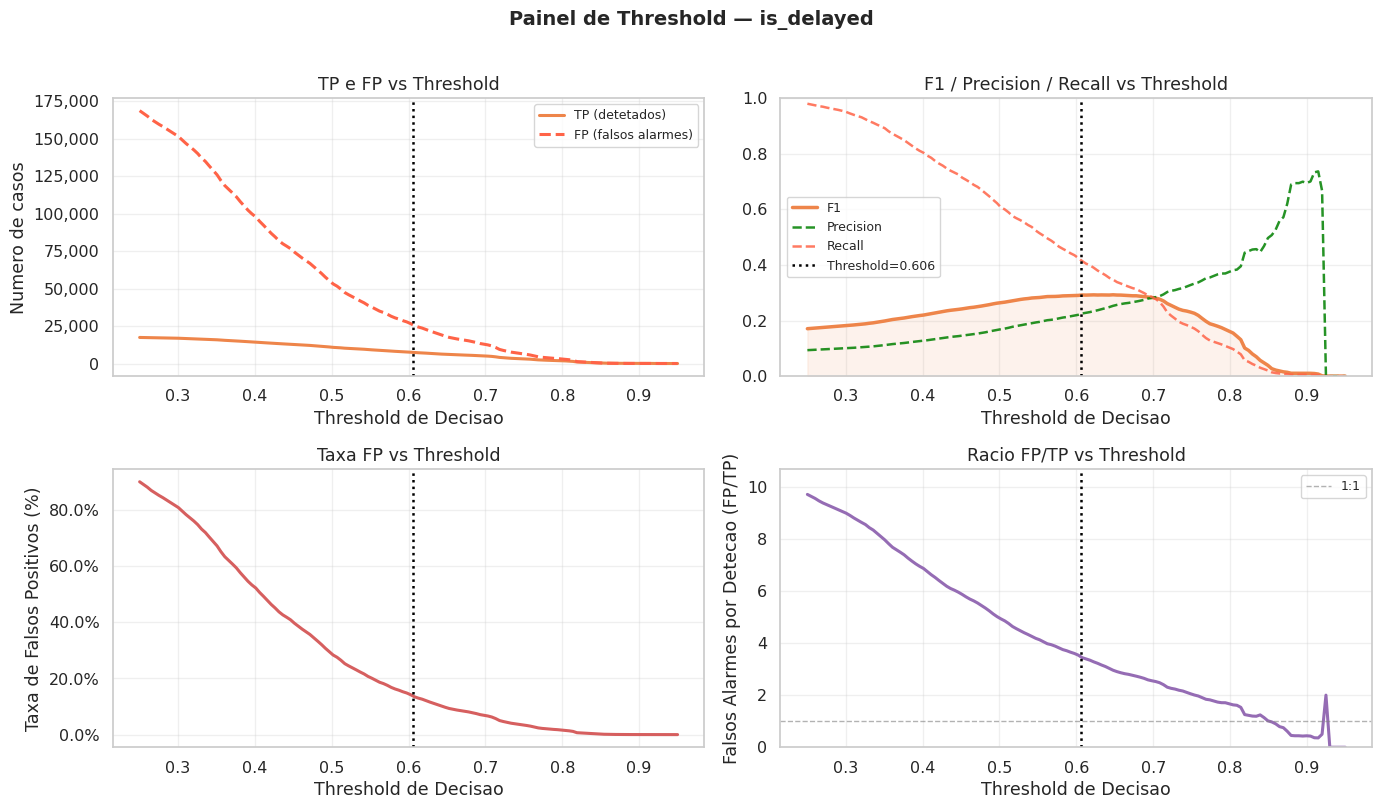

,TP,% detetados,FP,FP/TP,F1,Precision,Recall
Threshold,,,,,,,
0.400000,14275,80.5%,98200,6.9,0.219000,0.127000,0.805000
0.500000,10850,61.2%,53722,5.0,0.264000,0.168000,0.612000
0.600000,7649,43.1%,27325,3.6,0.290000,0.219000,0.431000
0.606000,7380,41.6%,25554,3.5,0.291000,0.224000,0.416000
0.700000,4984,28.1%,12646,2.5,0.282000,0.283000,0.281000
0.850000,344,1.9%,345,1.0,0.037000,0.499000,0.019000
0.900000,91,0.5%,40,0.4,0.010000,0.695000,0.005000


In [16]:
painel_threshold(y_test_d, proba_d, THRESH_D, COR_DEL,
                 'Painel de Threshold — is_delayed')

Situação substancialmente mais flexível: o pico de F1 é mais largo e o rácio FP/TP decresce mais suavemente ao subir o threshold. A 0.50 ainda existe Recall aceitável; a 0.70 a Precision sobe a custo do Recall — espaço real de ajuste que `cancelled` não tem, consequência direta do menor desequilíbrio (11:1 vs 64:1).


---

## 6. Síntese

Os dois modelos desenvolvidos têm valor prático real. Porém, as métricas absolutas ficam aquém do que seria desejável: `cancelled` (F1=0.166) está muito limitado pela raridade extrema do evento e pela ausência de dados meteorológicos em tempo real, que são a principal causa de cancelamentos mas não estão presentes no dataset. `is_delayed` é mais robusto (F1=0.291, FP/TP=3.5), mas enfrenta a mesma limitação estrutural.

O principal constrangimento não é o modelo — é o dataset. Com features históricas apenas, o teto de desempenho é baixo: os falsos negativos têm probabilidades medianas de 0.659 e 0.455, muito abaixo dos thresholds, indicando que o modelo não hesita — simplesmente não tem informação suficiente para os detetar. A incorporação de dados meteorológicos e operacionais em tempo real seria o passo mais impactante para melhorar ambos os modelos.

| | `cancelled` | `is_delayed` |
|---|---|---|
| Modelo | HistGradientBoosting | HistGradientBoosting |
| Desequilíbrio classes | 64:1 | 11:1 |
| Threshold ótimo | 0.806 | 0.606 |
| F1 | 0.166 | 0.291 |
| Average Precision | 0.100 | 0.226 |
| Recall | 0.327 | 0.416 |
| Falsos alarmes por deteção | 8.0 | 3.5 |
| Features-chave | Temporais + clima (ex:BUF, MDW) | Temporais + tráfego (ex:ORD, ATL) |
| Aeroportos críticos | RSW, DEN, MCI | TTN, ANC, BQN |
